In [2]:
import pandas as pd

df = pd.read_csv("KaggleV2-May-2016.csv")

print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

In [3]:
print(df.shape)

(110527, 14)


In [4]:
print(df.dtypes)

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object


In [5]:
elderly_patients = df[df["Age"] > 60]

print(elderly_patients[
    ["PatientId", "Gender", "Age", "Neighbourhood", "No-show"]
].head(10))

       PatientId Gender  Age    Neighbourhood No-show
0   2.987250e+13      F   62  JARDIM DA PENHA      No
2   4.262962e+12      F   62    MATA DA PRAIA      No
5   9.598513e+13      F   76        REPÚBLICA      No
24  8.734858e+12      F   65       TABUAZEIRO      No
32  5.288356e+13      M   61    SÃO CRISTÓVÃO      No
34  1.999976e+13      F   79    SÃO CRISTÓVÃO      No
36  7.298459e+13      F   63    SÃO CRISTÓVÃO      No
37  1.578132e+12      F   64       TABUAZEIRO      No
38  5.873316e+12      M   85    SÃO CRISTÓVÃO      No
41  8.224325e+14      F   71          MARUÍPE      No


In [6]:
no_show = df[df["No-show"] == "Yes"]

print(no_show[
    ["PatientId", "Gender", "Age", "Neighbourhood", "No-show"]
].head(10))

       PatientId Gender  Age   Neighbourhood No-show
6   7.336882e+14      F   23      GOIABEIRAS     Yes
7   3.449833e+12      F   39      GOIABEIRAS     Yes
11  7.542951e+12      M   29  NOVA PALESTINA     Yes
17  1.479497e+13      F   40       CONQUISTA     Yes
20  6.222575e+14      F   30  NOVA PALESTINA     Yes
21  1.215484e+13      F    4       CONQUISTA     Yes
22  8.632298e+14      M   13       CONQUISTA     Yes
31  3.112849e+11      M   12  NOVA PALESTINA     Yes
44  2.741649e+11      F   78   SÃO CRISTÓVÃO     Yes
48  8.545415e+12      F   58   SÃO CRISTÓVÃO     Yes


In [7]:
sorted_df = df.sort_values(
    by="Age",
    ascending=False
)

print(sorted_df[
    ["PatientId", "Gender", "Age", "Neighbourhood", "No-show"]
].head(10))

           PatientId Gender  Age    Neighbourhood No-show
68127   3.196321e+13      F  115       ANDORINHAS     Yes
97666   7.482346e+14      F  115         SÃO JOSÉ      No
63915   3.196321e+13      F  115       ANDORINHAS     Yes
63912   3.196321e+13      F  115       ANDORINHAS     Yes
76284   3.196321e+13      F  115       ANDORINHAS      No
58014   9.762948e+14      F  102        CONQUISTA      No
90372   2.342836e+11      F  102      MARIA ORTIZ      No
108506  3.939642e+11      F  100          MARUÍPE      No
79270   9.739430e+12      M  100       TABUAZEIRO      No
92084   5.578313e+13      F  100  ANTÔNIO HONÓRIO      No


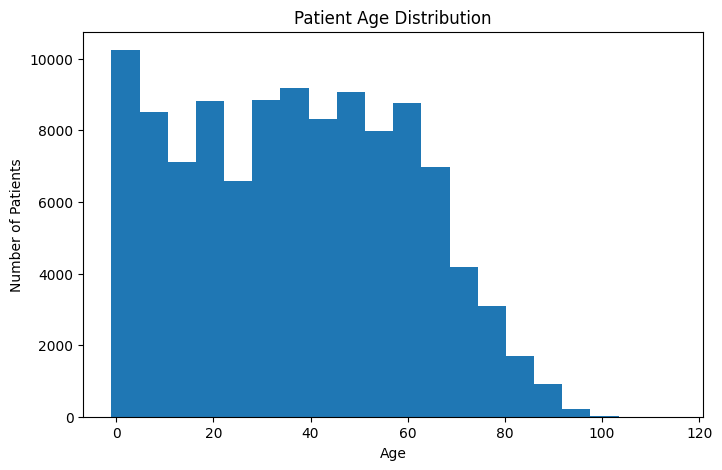

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [9]:
print("Mean =", df["Age"].mean())
print("Median =", df["Age"].median())
print("Mode =", df["Age"].mode()[0])
print("Standard Deviation =", df["Age"].std())

Mean = 37.08887421173107
Median = 37.0
Mode = 0
Standard Deviation = 23.110204963682644


In [10]:
print(df["Age"].describe())

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


In [11]:
gender_avg = df.groupby(
    "Gender"
)["Age"].mean()

print(gender_avg)

Gender
F    38.893987
M    33.736863
Name: Age, dtype: float64


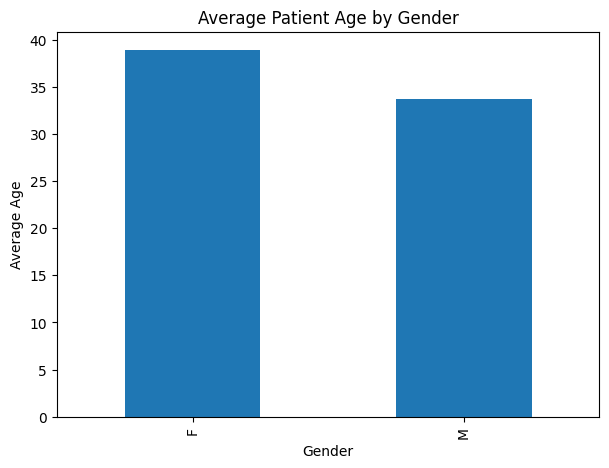

In [12]:
gender_avg.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Patient Age by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Age")

plt.show()

In [13]:
corr = df[
    ["Age", "SMS_received"]
].corr()

print(corr)

                   Age  SMS_received
Age           1.000000      0.012643
SMS_received  0.012643      1.000000
